In [2]:
import os
import cv2
import numpy as np
# for creating a responsive plot
# %matplotlib widget
# importing required libraries
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import torch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import frontalize
import subprocess
import importlib  
crop_video = importlib.import_module("crop-video")
%matplotlib inline
import glob
import webinterface
from tqdm import tqdm

In [7]:
for image_path in tqdm(glob.glob("../Datasets/EmotioNet/filtered_images/*.jpg")):
    try:
        identity = image_path.split("\\")[-1][:-4]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        webinterface.mirror_face_image(image, identity)
    except:
        pass
    
    

100%|██████████████████████████████████████████████████████████████████████████████| 5332/5332 [21:36<00:00,  4.11it/s]


In [11]:
identity

'N_0000000001_00016'

['../Datasets/EmotioNet/filtered_images\\N_0000000001_00016.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00018.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00024.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00030.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00050.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00053.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00058.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00061.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00062.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00072.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00082.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00091.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00094.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00098.jpg',
 '../Datasets/EmotioNet/filtered_images\\N_0000000001_00101.jpg',
 '../Datas

In [17]:
def get_half_face_masks(detection_result):
    landmarks = (np.array([[x.x, x.y] for x in detection_result.face_landmarks[0]])*256).astype(int)
    
    # landmark indices
    subset_landmarks_right = landmarks[[9, 18, 336, 296,334,293,300,197,195,5,4,1,17,314,405,321,375,432,427,340,280]]
    subset_landmarks_left = landmarks[[9, 18, 107, 66,105,63,70,139,50,207,57,43,106,182]]
    
    cvxhull_right = cv2.convexHull(subset_landmarks_right)
    cvxhull_left = cv2.convexHull(subset_landmarks_left)

    contour_mask_right = cv2.drawContours(np.zeros((256,256)), [cvxhull_right], -1, 255)
    contour_mask_left = cv2.drawContours(np.zeros((256,256)), [cvxhull_left], -1, 255)
    contour_mask_right = (contour_mask_right > 128).astype(float)
    contour_mask_left = (contour_mask_left > 128).astype(float)
    
    combined_mask_left = ((cv2.flip(contour_mask_right, 1) + contour_mask_left) >= 1).astype(int)
    combined_mask_right = ((cv2.flip(contour_mask_left, 1) + contour_mask_right) >= 1).astype(int)
    
    return combined_mask_left, combined_mask_right, contour_mask_left, contour_mask_right

In [4]:
def blend_side_face(front_image, combined_mask, mirrored, poisson=True, dilate=True):
    fH, fW = front_image.shape[:2]
    mH, mW = mirrored.shape[:2]
    
    W = min(mW,fW)
    if dilate:
        kernel = np.ones((7, 7), np.uint8) 
        combined_mask_padded = cv2.dilate((combined_mask * 255).astype("uint8"), kernel, iterations=1) / 255.
    else:
        combined_mask_padded = combined_mask
        
    cropped_side_face = mirrored
    coords = np.stack(np.where(combined_mask_padded  > 0.9),axis=1)
    ymin, xmin = np.min(coords, axis = 0)
    ymax, xmax = np.max(coords, axis = 0)
    center = [(xmax + xmin)//2,(ymax + ymin)//2 ]
    mask = ((combined_mask_padded > 0.9).astype(float) *255).astype("uint8")
    
    
    if poisson:
        blended1 = cv2.seamlessClone(cropped_side_face, front_image, mask, center, cv2.NORMAL_CLONE)
    else:
        blended1 = mirrored

    sigma = 3
    kernel_size = 11
    contour_mask_blurred = cv2.GaussianBlur((combined_mask_padded * 255).astype("uint8"), (kernel_size, kernel_size), sigma) / 255
    blended2 = front_image[:,:W] *(1 - contour_mask_blurred[:,:W,None])+ blended1[:,:W]*contour_mask_blurred[:,:W,None]
    
    return blended2.astype("uint8"), cropped_side_face

In [5]:
def blend_side_face(front_image, inpainted_image, mask, direction="right", poisson=True, dilate=True, dilate_kernel=11):
    
    flipped_face, mask_flipped = flip_mask_and_cropped_face(front_image, mask, direction)
    
    
    if dilate:
        kernel = np.ones((dilate_kernel, dilate_kernel), np.uint8) 
        mask_padded = cv2.dilate((mask_flipped * 255).astype("uint8"), kernel, iterations=1) / 255.
    else:
        mask_padded = mask_flipped
        
        
    cropped_side_face = (flipped_face * mask_padded[:,:,None]).astype("uint8")
    coords = np.stack(np.where(mask_padded  > 0.9),axis=1)
    ymin, xmin = np.min(coords, axis = 0)
    ymax, xmax = np.max(coords, axis = 0)
    center = [(xmax + xmin)//2,(ymax + ymin)//2 ]
    mask_poisson = ((mask_padded > 0.9).astype(float) *255).astype("uint8")
    
    
    if poisson:
        blended1 = cv2.seamlessClone(cropped_side_face, inpainted_image, mask_poisson, center, cv2.NORMAL_CLONE)
    else:
        blended1 = flipped_face

    sigma = 3
    kernel_size = 11
    contour_mask_blurred = cv2.GaussianBlur((mask_padded * 255).astype("uint8"), (kernel_size, kernel_size), sigma) / 255
    blended2 = inpainted_image *(1 - contour_mask_blurred[:,:,None])+ blended1[:,:]*contour_mask_blurred[:,:,None]
    
    return blended2.astype("uint8"), cropped_side_face

In [6]:
# def blend_side_face(front_image, combined_mask, mirrored, poisson=True, dilate=True):
#     fH, fW = front_image.shape[:2]
#     mH, mW = mirrored.shape[:2]
    
#     W = min(mW,fW)
#     if dilate:
#         kernel = np.ones((7, 7), np.uint8) 
#         combined_mask_padded = cv2.dilate((combined_mask * 255).astype("uint8"), kernel, iterations=1) / 255.
#     else:
#         combined_mask_padded = combined_mask
        
#     cropped_side_face = (combined_mask_padded[:,:W,None] * mirrored[:,:W]).astype("uint8")
#     coords = np.stack(np.where(combined_mask_padded  > 0.9),axis=1)
#     ymin, xmin = np.min(coords, axis = 0)
#     ymax, xmax = np.max(coords, axis = 0)
#     center = [(xmax + xmin)//2,(ymax + ymin)//2 ]
#     mask = ((combined_mask_padded > 0.9).astype(float) *255).astype("uint8")
    
    
#     if poisson:
#         blended1 = cv2.seamlessClone(cropped_side_face, front_image, mask, center, cv2.NORMAL_CLONE)
#     else:
#         blended1 = mirrored

#     sigma = 3
#     kernel_size = 11
#     contour_mask_blurred = cv2.GaussianBlur((combined_mask_padded * 255).astype("uint8"), (kernel_size, kernel_size), sigma) / 255
#     blended2 = front_image[:,:W] *(1 - contour_mask_blurred[:,:W,None])+ blended1[:,:W]*contour_mask_blurred[:,:W,None]
    
#     return blended2.astype("uint8"), cropped_side_face

In [7]:
def flip_mask_and_cropped_face(face_image, mask, mask_direction="right"):
    H,W = mask.shape
    orig_left_pt = np.min(np.where(np.sum(mask, axis=0) > 0))
    orig_right_pt = np.max(np.where(np.sum(mask, axis=0) > 0))
    
    face_flipped = cv2.flip(face_image,1)
    mask_flipped = cv2.flip(mask,1)
    
    right_pt = np.max(np.where(np.sum(mask_flipped, axis=0) > 0))
    left_pt = np.min(np.where(np.sum(mask_flipped, axis=0) > 0))
    mask_width = right_pt - left_pt
    tmp_mask = np.zeros_like(mask)
    tmp_face = np.zeros_like(face_image)
    
    
    
    if mask_direction == "right":
        tmp_mask[:,orig_left_pt - mask_width:orig_left_pt] = mask_flipped[:,left_pt:right_pt]
        tmp_face[:,orig_left_pt - mask_width:orig_left_pt] = face_flipped[:,left_pt:right_pt]
        
        if orig_left_pt - mask_width > left_pt:
            st = orig_left_pt - mask_width - left_pt
            tmp_face[:,st:orig_left_pt - mask_width] = face_flipped[:,:left_pt]
        else:
            st = left_pt - (orig_left_pt - mask_width)
            tmp_face[:,:orig_left_pt - mask_width] = face_flipped[:,st:left_pt]

        if orig_left_pt > right_pt:
            end = orig_left_pt - right_pt
            tmp_face[:,orig_left_pt:] = face_flipped[:,right_pt:W - end]
        else:
            end = right_pt - orig_left_pt
            tmp_face[:,orig_left_pt:W - end] = face_flipped[:,right_pt:]
            
    else:
        tmp_mask[:,orig_right_pt + 1:orig_right_pt + mask_width + 1] = mask_flipped[:,left_pt:right_pt]
        tmp_face[:,orig_right_pt + 1:orig_right_pt + mask_width + 1] = face_flipped[:,left_pt:right_pt]
        
        if orig_right_pt + 1 > left_pt:
            st = orig_right_pt + 1 - left_pt
            tmp_face[:,st:orig_right_pt + 1] = face_flipped[:,:left_pt]
        else:
            st = left_pt - (orig_right_pt + 1)
            tmp_face[:,:orig_right_pt + 1] = face_flipped[:,st:left_pt]

        if orig_right_pt + mask_width + 1 > right_pt:
            end = orig_right_pt + mask_width + 1 - right_pt
            tmp_face[:,orig_right_pt + mask_width + 1:] = face_flipped[:,right_pt:W - end]
        else:
            end = right_pt - (orig_right_pt + mask_width + 1)
            tmp_face[:,orig_right_pt + mask_width + 1:W - end] = face_flipped[:,right_pt:]
        
    mask_flipped = tmp_mask
    face_flipped = tmp_face
    return face_flipped.astype("uint8"), mask_flipped

In [8]:
im_name = "N_0000000020_00600-frontal.png"
image = cv2.imread(im_name)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [9]:
frontal_image, mirror_l, mirror_r, detection_result = frontalize.frontalize_and_mirror(image,with_3d_rotate=True)

In [18]:
combined_mask_left, combined_mask_right, contour_mask_left, contour_mask_right = get_half_face_masks(detection_result)

In [11]:
inpaint_left = cv2.inpaint(frontal_image, (contour_mask_left * 255).astype("uint8"), 3, cv2.INPAINT_TELEA)
inpaint_right = cv2.inpaint(frontal_image, (contour_mask_right * 255).astype("uint8"), 3, cv2.INPAINT_TELEA)

blended_left, cropped_side_face_left = blend_side_face(frontal_image, inpaint_right, contour_mask_left, direction="left", poisson=False,  dilate=False)
blended_right,cropped_side_face_right = blend_side_face(frontal_image, inpaint_left, contour_mask_right, direction="right", poisson=False, dilate=False)

Text(0.5, 1.0, 'original mirroring left')

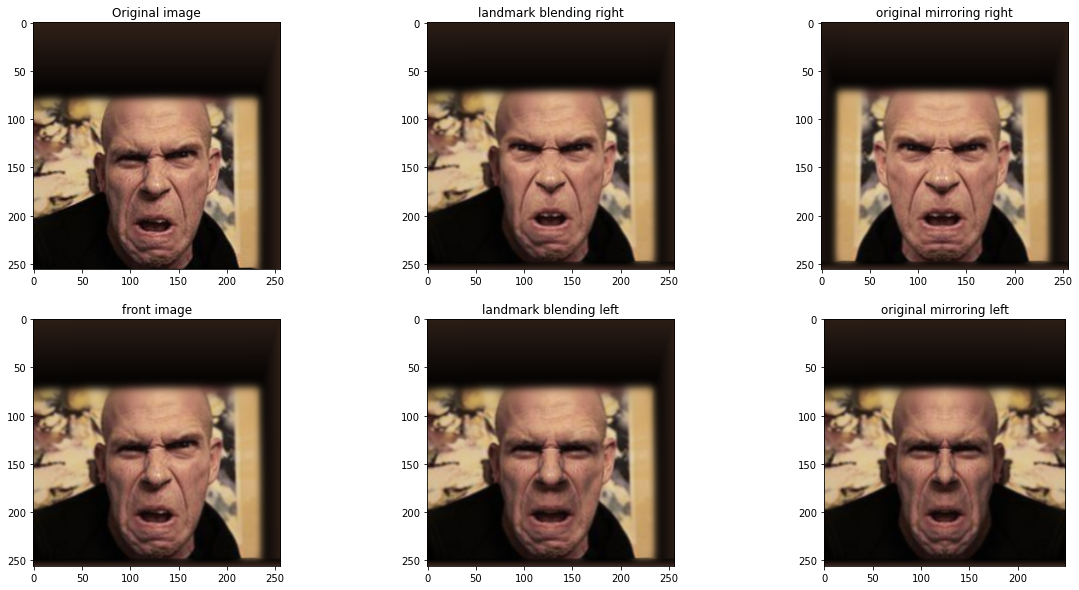

In [12]:
plt.figure(figsize=(20,10))
plt.subplot(231)
plt.imshow(image)
plt.title("Original image")
plt.subplot(232)
plt.imshow(blended_right)
plt.title("landmark blending right")
plt.subplot(233)
plt.imshow(mirror_r)
plt.title("original mirroring right")

plt.subplot(234)
plt.imshow(frontal_image)
plt.title("front image")
plt.subplot(235)
plt.imshow(blended_left)
plt.title("landmark blending left")
plt.subplot(236)
plt.imshow(mirror_l)
plt.title("original mirroring left")

# plt.savefig(im_name+"_mirroring.jpg", bbox_inches="tight", dpi=300)

In [13]:
lmarks = [[x.x,x.y] for x in detection_result.face_landmarks[0]] * np.array([256,256])

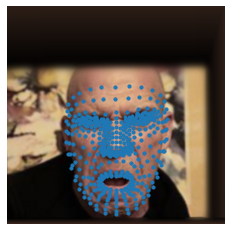

In [14]:
plt.imshow(frontal_image)
plt.scatter(lmarks[:,0],lmarks[:,1], s=10)
plt.axis("off")
plt.savefig("{}-landmarks.png".format(im_name[:-4]), bbox_inches="tight", pad_inches=0)

(-0.5, 255.5, 255.5, -0.5)

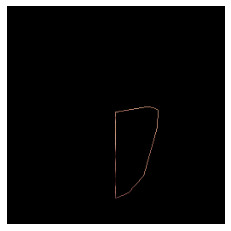

In [19]:
plt.imshow(frontal_image / 255* contour_mask_right[:,:,None])
plt.axis("off")
# plt.savefig("{}-leftface.png".format(im_name[:-4]), bbox_inches="tight", pad_inches=0)

(-0.5, 255.5, 255.5, -0.5)

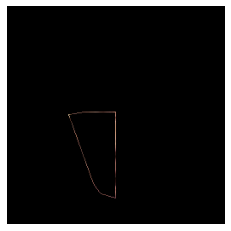

In [20]:
plt.imshow(frontal_image / 255* contour_mask_left[:,:,None])
plt.axis("off")
# plt.savefig("{}-rightface.png".format(im_name[:-4]), bbox_inches="tight", pad_inches=0)

In [30]:
tmp = np.zeros((256,256,3))
tmp[:,:,2] = contour_mask_right

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


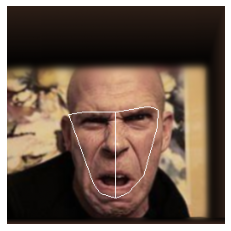

In [33]:
plt.imshow(frontal_image / 255 + contour_mask_right[:,:,None]  + contour_mask_left[:,:,None])
plt.axis("off")
plt.savefig("{}-facecontour.png".format(im_name[:-4]), bbox_inches="tight", pad_inches=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 255.5, 255.5, -0.5)

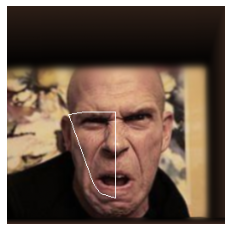

In [24]:
plt.imshow(frontal_image / 255 + contour_mask_left[:,:,None])
plt.axis("off")
# plt.savefig("{}-rightface.png".format(im_name[:-4]), bbox_inches="tight", pad_inches=0)

In [24]:
# cv2.imwrite(im_name+"_front_mirrored.png", blended_right[:,:,::-1])

In [16]:
def crop_face_video(input_video, output_video):
    crop_script = crop_video.process_video_function(input_video, output_video)
    print(crop_script)
    process = subprocess.Popen(crop_script[0], shell=True, stdout=subprocess.PIPE)
    process.wait()
# print (process.returncode)

In [17]:
# crop_face_video("vid.mp4","test.mp4")

In [2]:
frontalize.crop_video("sample.mp4","original_video.mp4")

1000.0 4598


E0000 00:00:1709559977.152002   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559977.152036   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559977.160402   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559977.194131   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559977.194142   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559977.194148   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559978.192763   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559978.192814   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559978.201192   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559978.236644   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559978.236661   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559978.236666   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559979.226272   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559979.226306   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559979.234845   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559979.269126   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559979.269136   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559979.269142   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559980.261547   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559980.261589   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559980.270567   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559980.305532   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559980.305547   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559980.305553   11810 gl_context.cc:408] INTERNAL: ; 

...

E0000 00:00:1709559988.503085   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559988.503121   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559988.511643   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559988.546633   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559988.546649   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559988.546654   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559989.531368   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559989.531403   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559989.539882   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559989.573968   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559989.573977   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559989.573983   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559990.554399   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559990.554437   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559990.562876   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559990.596472   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559990.596482   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559990.596488   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559991.583927   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559991.583965   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559991.592314   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559991.626890   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559991.626902   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559991.626907   11810 gl_context.cc:408] INTERNAL: ; 

E0000 00:00:1709559992.609340   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
I0000 00:00:1709559992.609376   11810 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x300c
W0000 00:00:1709559992.618197   11810 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
E0000 00:00:1709559992.653660   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559992.653674   11810 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1709559992.653680   11810 gl_context.cc:408] INTERNAL: ; 

Text(0.5, 1.0, 'original mirroring')

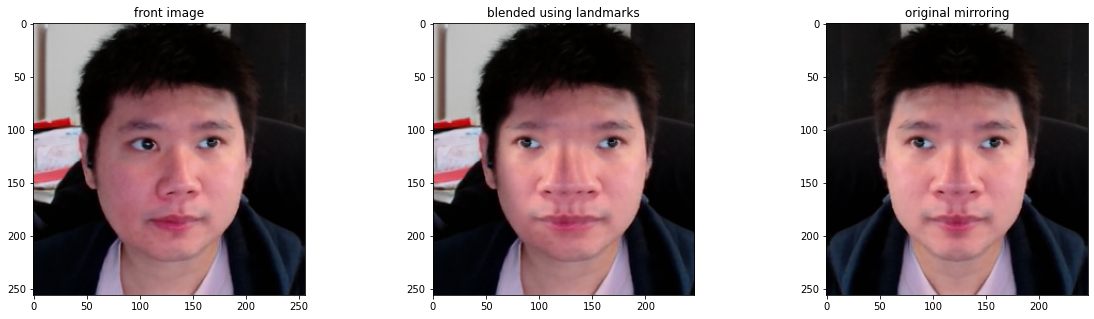

In [18]:


plt.figure(figsize=(20,5))
plt.subplot(131)
plt.imshow(frontal_image)
plt.title("front image")
plt.subplot(132)
plt.imshow(blended_left)
plt.title("blended using landmarks")
plt.subplot(133)
plt.imshow(mirror_l)
plt.title("original mirroring")

Text(0.5, 1.0, 'original mirroring')

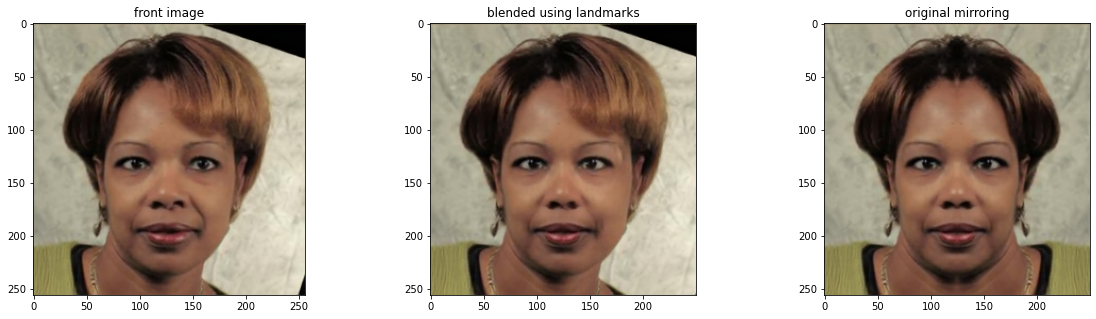

In [29]:

blended_right = blend_side_face(frontal_image, combined_mask_right, mirror_r, dilate=False)
plt.figure(figsize=(20,5))
plt.subplot(131)
plt.imshow(frontal_image)
plt.title("front image")
plt.subplot(132)
plt.imshow(blended_right)
plt.title("blended using landmarks")
plt.subplot(133)
plt.imshow(mirror_r)
plt.title("original mirroring")

In [10]:

from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize.
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.
    face_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    face_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in face_landmarks
    ])

    solutions.drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks_proto,
        connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp.solutions.drawing_styles
        .get_default_face_mesh_tesselation_style())
    solutions.drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks_proto,
        connections=mp.solutions.face_mesh.FACEMESH_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp.solutions.drawing_styles
        .get_default_face_mesh_contours_style())
    solutions.drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks_proto,
        connections=mp.solutions.face_mesh.FACEMESH_IRISES,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp.solutions.drawing_styles
          .get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

In [11]:


# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("debug_rot.png")

# STEP 4: Detect face landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)



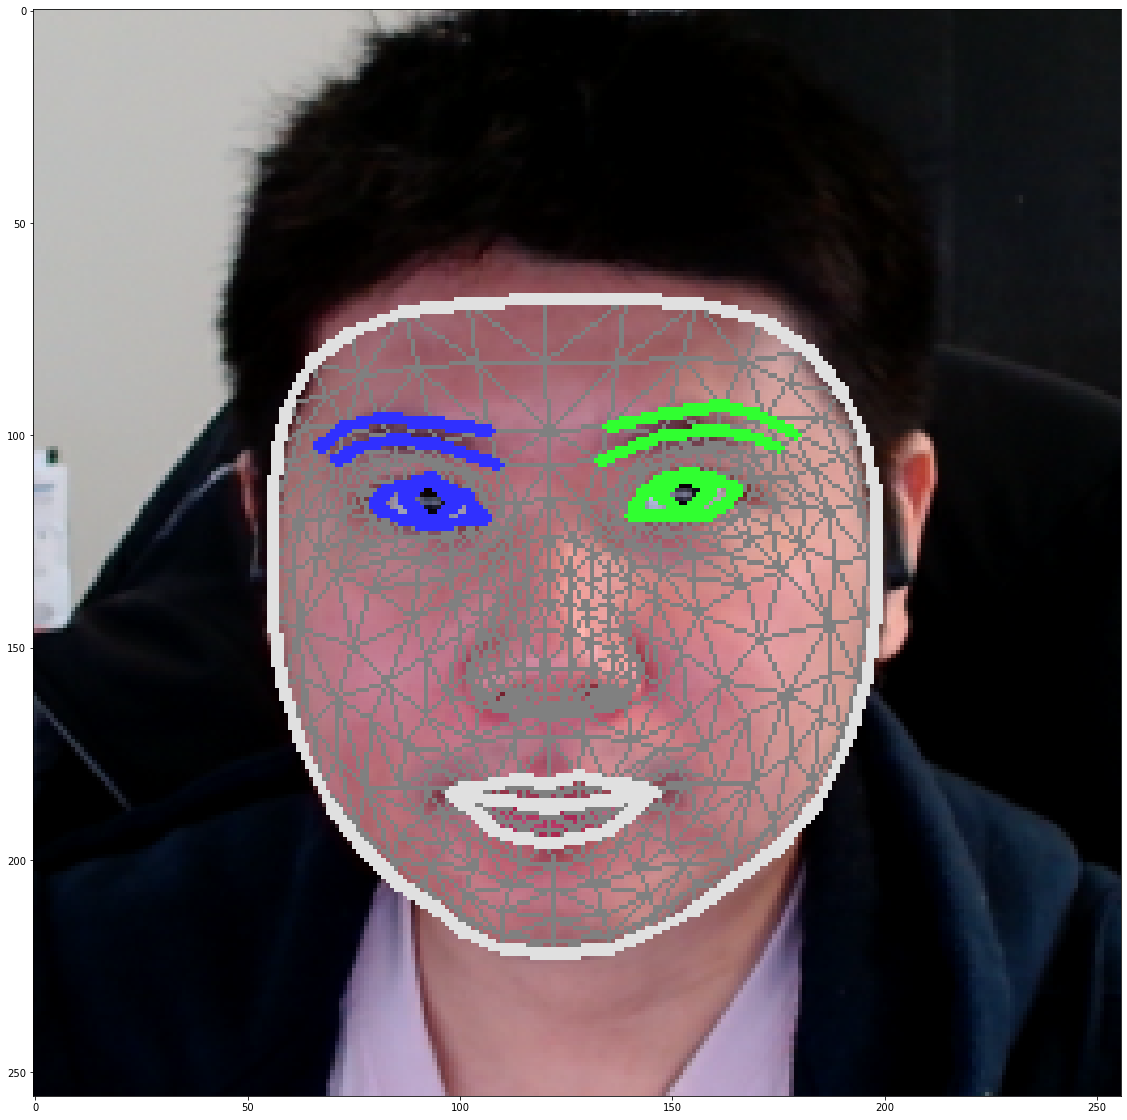

In [12]:
plt.figure(figsize=(20,20))
plt.imshow(annotated_image)


In [58]:
np.cos(11.86039985475867 * np.pi / 180)

0.9786512700019003